# Clasificador de Edad por DÉCADA — UTKFace

Clasificación multiclase (**9 clases** por década) a partir de imágenes de rostros, implementado en **PyTorch** y **TensorFlow/Keras**.

**Categorías de edad:**

| Clase | Rango |
|---|---|
| 0 | 0–9 |
| 1 | 10–19 |
| 2 | 20–29 |
| 3 | 30–39 |
| 4 | 40–49 |
| 5 | 50–59 |
| 6 | 60–69 |
| 7 | 70–79 |
| 8 | 80+ |

> ## 📌 Banco de entrenamiento: carpeta única UTKFace (balanceo por muestreo, sin subcarpetas)
>
> Este notebook entrena leyendo **directamente** desde la carpeta original descargada, sin subcarpetas por década (así no hay imágenes duplicadas en el repo):
> - Carpeta: `./UTKFace_data/UTKFace`
> - La etiqueta (década) y la etnia se calculan en Python a partir del **nombre de archivo** (`[edad]_[género]_[raza]_[fecha].jpg`), usando `parse_age_from_filename` + `age_to_decade` para la edad, y `parse_race_from_filename` para la etnia.
> - Para mantener las clases balanceadas, se cuenta cuántas imágenes hay por década y se **muestrea aleatoriamente** (semilla fija) el mínimo común (`cap`) de cada una — igual N° de imágenes por década, sin necesidad de `class_weight` / `WeightedRandomSampler`.
>
> **Etnia por categoría (de las fotos elegidas):** aunque el banco está balanceado por *edad*, la composición *étnica* varía mucho entre categorías (ver celda "Distribución por etnia"). Códigos UTKFace: `White, Black, Asian, Indian, Others` (los latinos/hispanos caen en **Others**; UTKFace no tiene etiqueta propia para ellos).
>
> ⚠️ **Sesgo a tener presente:** como la mezcla étnica difiere por edad, el modelo podría apoyarse en rasgos étnicos para predecir la edad.
>
> 👉 Otros notebooks: `clasificador_edad_utkface.ipynb` (5 clases, balanceado por muestreo) y `clasificador_edad_utkface_RESULTADOS_completo.ipynb` (5 clases, UTKFace completo desbalanceado).

## 0. Descarga del dataset (UTKFace)

**Opción A — Kaggle API (recomendado):**

```bash
pip install kaggle
# 1. Crea una cuenta en kaggle.com si no tienes
# 2. Ve a kaggle.com/settings -> API -> "Create New Token" (descarga kaggle.json)
# 3. Coloca kaggle.json en ~/.kaggle/kaggle.json (Linux/Mac) o C:\Users\<usuario>\.kaggle\kaggle.json (Windows)

kaggle datasets download -d jangedoo/utkface-new
unzip utkface-new.zip -d ./UTKFace_data
```

**Opción B — Descarga manual:**

1. Ve a https://www.kaggle.com/datasets/jangedoo/utkface-new
2. Descarga el .zip (botón Download)
3. Descomprime y deja la carpeta de imágenes en `./UTKFace_data/UTKFace/` (debe contener directamente los .jpg, sin subcarpetas extra)

**Estructura esperada:**
```
UTKFace_data/
  UTKFace/
    1_0_0_20161219140623097.jpg
    2_1_3_20170109150557335.jpg
    ...
```

El nombre de cada archivo sigue el formato `[edad]_[género]_[raza]_[fecha].jpg`. Solo usaremos el campo `edad`.

In [11]:
!pip install pandas matplotlib seaborn scikit-learn torch tensorflow pillow

In [12]:
# --- Configuración general ---
import os
import re
import glob
import numpy as np
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"     # carpeta única con todas las imágenes (sin subcarpetas por década)
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [13]:
# --- Categorías por década y utilidades ---
CLASS_NAMES = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

# Códigos de etnia de UTKFace (campo 3 del nombre de archivo)
RACE_NAMES = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Others"}

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

def age_to_decade(age: int) -> int:
    """Convierte una edad entera al índice de década (0-8): 0-9, 10-19, ..., 80+."""
    return min(age // 10, 8)

def parse_race_from_filename(filename: str):
    """Extrae el código de etnia (0-4) del nombre '[edad]_[genero]_[raza]_[fecha].jpg'. None si no calza."""
    parts = os.path.basename(filename).split("_")
    try:
        race = int(parts[2])
        return race if race in RACE_NAMES else None
    except (ValueError, IndexError):
        return None

In [14]:
# --- Construcción del dataframe desde la carpeta única UTKFace ---
# La etiqueta (década) se calcula parseando la edad del NOMBRE DE ARCHIVO (no hay subcarpetas por década).
# Para balancear sin duplicar imágenes en disco: se muestrea aleatoriamente el mínimo común (cap)
# de imágenes por década, con semilla fija para reproducibilidad.
# Además guardamos la etnia (del nombre de archivo) para el análisis posterior.
all_fps = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
if len(all_fps) == 0:
    raise FileNotFoundError(
        f"No hay imágenes en '{DATA_DIR}'. Revisa que la carpeta UTKFace exista con los .jpg "
        "directamente adentro (ver celda de descarga del dataset)."
    )

records_by_class = {i: [] for i in range(len(CLASS_NAMES))}
skipped = 0
for fp in all_fps:
    age = parse_age_from_filename(fp)
    if age is None:
        skipped += 1
        continue
    records_by_class[age_to_decade(age)].append(fp)

print(f"Imágenes totales encontradas: {len(all_fps)}  |  Descartadas (nombre no calza el formato): {skipped}")
print("Disponibles por década (antes de balancear):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {len(records_by_class[i])}")

cap = min(len(fps) for fps in records_by_class.values())
print(f"\nCap por década (mínimo común): {cap}")

rng = np.random.RandomState(SEED)
records = []
for label_idx, fps in records_by_class.items():
    sampled = rng.choice(fps, size=cap, replace=False)
    for fp in sampled:
        records.append({"filepath": fp, "label": label_idx, "race": parse_race_from_filename(fp)})

df = pd.DataFrame(records, columns=["filepath", "label", "race"])
print(f"\nImágenes usadas para entrenar (balanceado): {len(df)}")
print("Por clase:")
print(df["label"].value_counts().sort_index().rename(index=lambda i: CLASS_NAMES[i]))
df.head()

Imágenes totales encontradas: 23708  |  Descartadas (nombre no calza el formato): 3
Disponibles por década (antes de balancear):
  0-9: 3062
  10-19: 1531
  20-29: 7344
  30-39: 4536
  40-49: 2245
  50-59: 2299
  60-69: 1316
  70-79: 699
  80+: 673

Cap por década (mínimo común): 673

Imágenes usadas para entrenar (balanceado): 6057
Por clase:
label
0-9      673
10-19    673
20-29    673
30-39    673
40-49    673
50-59    673
60-69    673
70-79    673
80+      673
Name: count, dtype: int64


,filepath,label,race
0,./UTKFace_data/UTKFace\3_1_0_20170109193833863...,0,0
1,./UTKFace_data/UTKFace\1_0_2_20161219154041477...,0,2
2,./UTKFace_data/UTKFace\2_1_0_20161219190909739...,0,0
3,./UTKFace_data/UTKFace\2_1_2_20161219162334438...,0,2
4,./UTKFace_data/UTKFace\2_1_4_20161221202428169...,0,4


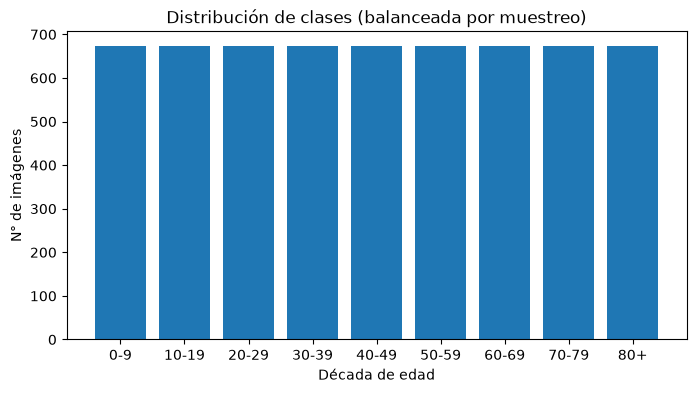

label
0-9      673
10-19    673
20-29    673
30-39    673
40-49    673
50-59    673
60-69    673
70-79    673
80+      673
Name: count, dtype: int64


In [15]:
# --- Distribución de clases (por década) ---
counts = df["label"].value_counts().reindex(range(len(CLASS_NAMES)), fill_value=0)
plt.figure(figsize=(8, 4))
plt.bar(CLASS_NAMES, counts.values)
plt.title("Distribución de clases (balanceada por muestreo)")
plt.ylabel("N° de imágenes")
plt.xlabel("Década de edad")
plt.show()

print(counts.rename(index=lambda i: CLASS_NAMES[i]))
# Balanceado por muestreo (cap = mínimo común entre décadas) -> barras del mismo alto.

Distribución de etnia por categoría de edad (%):

race_name  White  Black  Asian  Indian  Others
0-9         35.2    4.2   34.2    15.0    11.4
10-19       61.4   10.3    5.8    10.8    11.7
20-29       23.8   26.6   18.1    21.4    10.1
30-39       39.1   25.1   11.0    18.4     6.4
40-49       48.1   17.7    7.0    22.3     4.9
50-59       61.1   13.1    5.3    18.1     2.4
60-69       63.0   16.0    6.8    12.6     1.5
70-79       68.2   12.6   12.0     6.8     0.3
80+         71.8    8.6   15.2     3.9     0.6


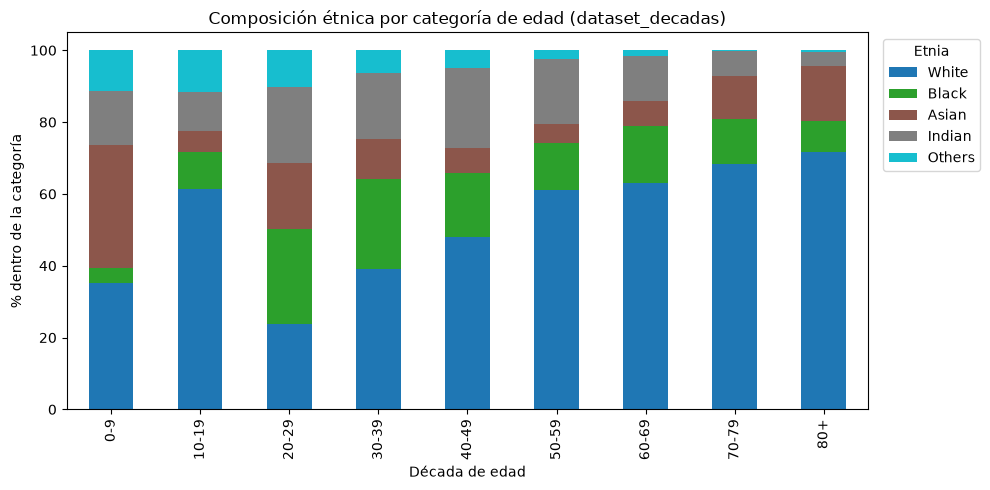

In [16]:
# --- Distribución por ETNIA dentro de cada categoría de edad ---
# Porcentaje de cada etnia (columnas) en cada década (filas).
tab = (
    df.assign(race_name=df["race"].map(RACE_NAMES))
      .pivot_table(index="label", columns="race_name", aggfunc="size", fill_value=0)
      .reindex(range(len(CLASS_NAMES)))
)
tab.index = [CLASS_NAMES[i] for i in tab.index]
tab = tab.reindex(columns=[RACE_NAMES[r] for r in range(5)], fill_value=0)

pct = tab.div(tab.sum(axis=1), axis=0) * 100  # % por fila

print("Distribución de etnia por categoría de edad (%):\n")
print(pct.round(1).to_string())

# Gráfico de barras apiladas (100% por categoría)
ax = pct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab10")
ax.set_title("Composición étnica por categoría de edad (dataset_decadas)")
ax.set_ylabel("% dentro de la categoría")
ax.set_xlabel("Década de edad")
ax.legend(title="Etnia", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Nota: 'Others' incluye hispanos/latinos; UTKFace no tiene etiqueta 'Latino' propia.

In [17]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 4239  |  Val: 909  |  Test: 909


## Parte A — PyTorch

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [19]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=9, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [20]:
# --- Entrenamiento (PyTorch) ---
ti_pt = time.time()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

tf_pt = time.time()
t_total_pt = tf_pt - ti_pt
print(f"\nTiempo total de entrenamiento (PyTorch): {t_total_pt:.2f} segundos")

Epoch 1/10 | train_loss=2.0554 train_acc=0.2019 | val_loss=1.7781 val_acc=0.3157
Epoch 2/10 | train_loss=1.7184 train_acc=0.3241 | val_loss=1.6027 val_acc=0.3597
Epoch 3/10 | train_loss=1.5613 train_acc=0.3798 | val_loss=1.5493 val_acc=0.3762
Epoch 4/10 | train_loss=1.4941 train_acc=0.4058 | val_loss=1.4903 val_acc=0.4103
Epoch 5/10 | train_loss=1.4019 train_acc=0.4381 | val_loss=1.4484 val_acc=0.4004
Epoch 6/10 | train_loss=1.3174 train_acc=0.4697 | val_loss=1.4383 val_acc=0.4378
Epoch 7/10 | train_loss=1.2385 train_acc=0.5112 | val_loss=1.4235 val_acc=0.4279
Epoch 8/10 | train_loss=1.1677 train_acc=0.5310 | val_loss=1.4362 val_acc=0.4268
Epoch 9/10 | train_loss=1.0922 train_acc=0.5622 | val_loss=1.4224 val_acc=0.4290
Epoch 10/10 | train_loss=1.0063 train_acc=0.5938 | val_loss=1.5489 val_acc=0.4136

Tiempo total de entrenamiento (PyTorch): 254.38 segundos


              precision    recall  f1-score   support

         0-9       0.77      0.88      0.82       101
       10-19       0.61      0.33      0.43       101
       20-29       0.36      0.56      0.44       101
       30-39       0.26      0.29      0.27       101
       40-49       0.33      0.19      0.24       101
       50-59       0.38      0.33      0.35       101
       60-69       0.30      0.44      0.35       101
       70-79       0.21      0.17      0.19       101
         80+       0.55      0.53      0.54       101

    accuracy                           0.41       909
   macro avg       0.42      0.41      0.40       909
weighted avg       0.42      0.41      0.40       909



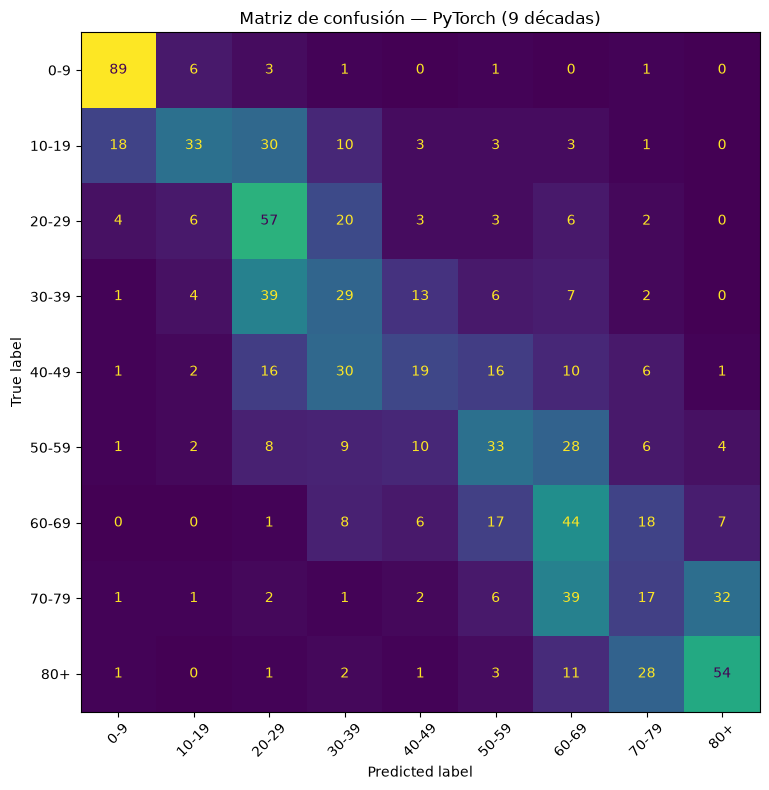

In [21]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — PyTorch (9 décadas)")
plt.tight_layout()
plt.show()

## Parte B — TensorFlow / Keras

In [22]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [23]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 549,161 (2.09 MB)

 Trainable params: 549,161 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# --- Entrenamiento (Keras) ---
ti2=time.time()
EPOCHS_TF = 10
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)
tf2=time.time()
t_total_tf = tf2 - ti2
print(f"\nTiempo total de entrenamiento (Keras): {t_total_tf:.2f} segundos")

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.1538 - loss: 2.1651 - val_accuracy: 0.2585 - val_loss: 1.9811
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.2857 - loss: 1.8536 - val_accuracy: 0.3520 - val_loss: 1.6472
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.3593 - loss: 1.6401 - val_accuracy: 0.3850 - val_loss: 1.5639
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.3895 - loss: 1.5323 - val_accuracy: 0.3806 - val_loss: 1.4842
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.4190 - loss: 1.4635 - val_accuracy: 0.4202 - val_loss: 1.4668
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.4444 - loss: 1.3831 - val_accuracy: 0.4191 - val_loss: 1.4293
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.4798 - loss: 1.3099 - val_accuracy: 0.4213 - val_loss: 1.4103
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.5077 - loss: 1.2298 - va

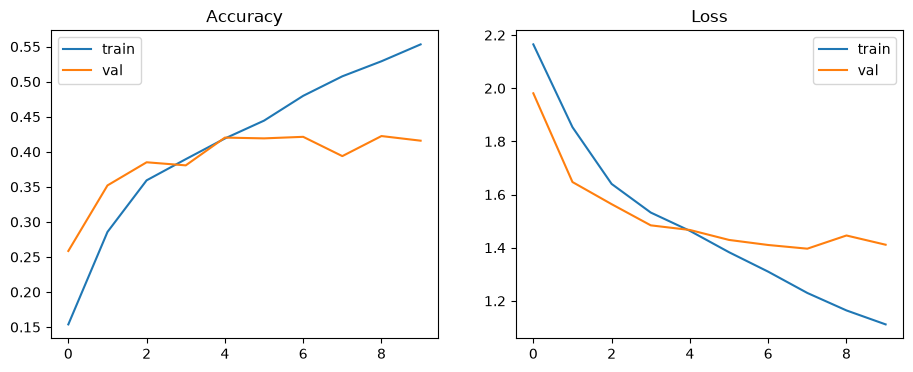

In [25]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

         0-9       0.83      0.84      0.84       101
       10-19       0.49      0.60      0.54       101
       20-29       0.31      0.27      0.29       101
       30-39       0.19      0.10      0.13       101
       40-49       0.32      0.39      0.35       101
       50-59       0.28      0.33      0.30       101
       60-69       0.32      0.39      0.35       101
       70-79       0.23      0.17      0.19       101
         80+       0.61      0.63      0.62       101

    accuracy                           0.41       909
   macro avg       0.40      0.41      0.40       909
weighted avg       0.40      0.41      0.40       909



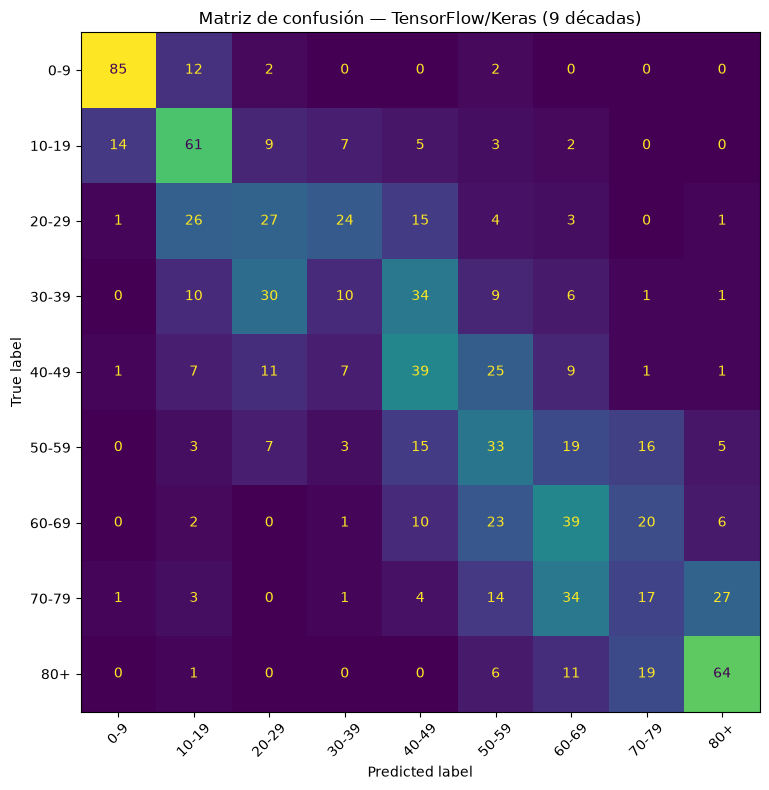

In [26]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — TensorFlow/Keras (9 décadas)")
plt.tight_layout()
plt.show()

## Comparación final

_(Completa aquí: accuracy de cada framework en test, qué clases se confunden más entre sí — probablemente 'joven' vs 'adulto' y 'adolescente' vs 'joven' por la ambigüedad visual en los límites de rango — y qué cambiarías para mejorar el modelo: más datos, balanceo de clases, augmentación, transfer learning, etc.)_